In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from scipy.interpolate import interp1d 
from scipy.signal import savgol_filter

from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import WaveformGeneratorFRef
from Triangle_BBH.Response import FDTDIResponseGeneratorFRef
from Triangle_BBH.Utils import * 
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")
    
import bilby 

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


## Load TDC data 

In [2]:
h5filename = "/Users/taijidatacenter/workspace/TDCData/2_2_MBHB_PhenomT_TDIXYZ.h5"
with h5py.File(h5filename, "r") as h5file: 
    data_dict = read_dict_from_h5(h5file["/"])

h5paramfilename = "/Users/taijidatacenter/workspace/TDCData/2_2_MBHB_PhenomT_parameters.h5"
with h5py.File(h5paramfilename, "r") as h5file: 
    fiducial_parameters = read_dict_from_h5(h5file["/"])

data_dict, fiducial_parameters

({'XYZ': {'X2': array([-4.16859165e-21,  4.11261519e-21, -1.32699486e-20, ...,
           9.66198203e-21, -7.21925774e-21,  3.92075810e-21]),
   'Y2': array([ 1.98093593e-21,  1.99164607e-21, -1.25513428e-20, ...,
           2.67657559e-20, -1.17870167e-20, -7.00005575e-22]),
   'Z2': array([-7.12101574e-22,  5.10927806e-21, -1.16908050e-20, ...,
           1.77932096e-20, -1.17802760e-20,  2.79656549e-22])},
  'time': array([2.0000000e+03, 2.0050000e+03, 2.0100000e+03, ..., 3.1471735e+07,
         3.1471740e+07, 3.1471745e+07])},
 {'chirp_mass': array([6301109.85843637, 1938311.50869768,  948252.13486173,
         1655772.19023232,  144882.07681983, 2083011.91604992,
         2461142.81748617,  637099.50778762, 2053358.73686789,
          135796.62221691,  430813.53512855,  710293.77707233,
         4180656.38010106, 2304817.05692089, 2444813.37721959,
         3045843.74569863, 1586784.45597077,  629200.00140672,
          706972.71824866, 3389590.22205183, 2380007.64444597,
        

## Slice data 

In [3]:
start_time = 321.5 * DAY 
Tobs = 2 * DAY 
dt = data_dict["time"][1] - data_dict["time"][0]
end_time = start_time + Tobs

slice_idx = np.where((data_dict["time"]>=start_time)&(data_dict["time"]<=end_time))[0]
data_time = data_dict["time"][slice_idx]
data_channels_td = np.array(AETfromXYZ(
    data_dict["XYZ"]["X2"][slice_idx], 
    data_dict["XYZ"]["Y2"][slice_idx], 
    data_dict["XYZ"]["Z2"][slice_idx]
    ))
data_channels_td = -data_channels_td # NOTE: due to our convension for TDI channel in the FDResponse model

channel_names = ["A", "E", "T"]
channel_colors = [RED, BLUE, ORANGE]

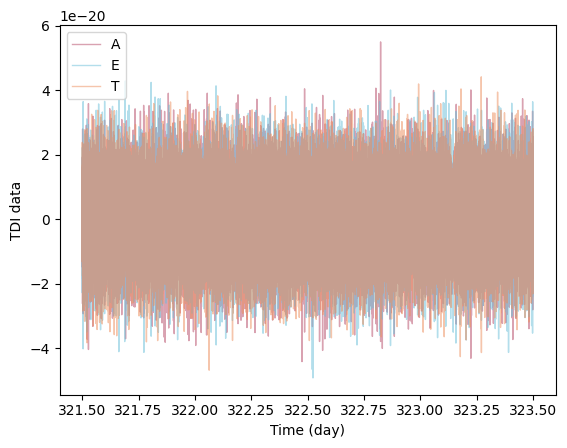

In [4]:
for i in range(3): 
    plt.plot(data_time / DAY, data_channels_td[i], linewidth=1, color=channel_colors[i], label=channel_names[i], alpha=0.5)
plt.xlabel("Time (day)")
plt.ylabel("TDI data")
plt.legend()

## Fourier transform

In [5]:
data_channels_fd = [] 
for i in range(3): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=0.05)
        )
    data_channels_fd.append(xf * np.exp(-TWOPI * 1.j * ff * start_time)) 
data_channels_fd = np.array(data_channels_fd)
data_frequency = ff 

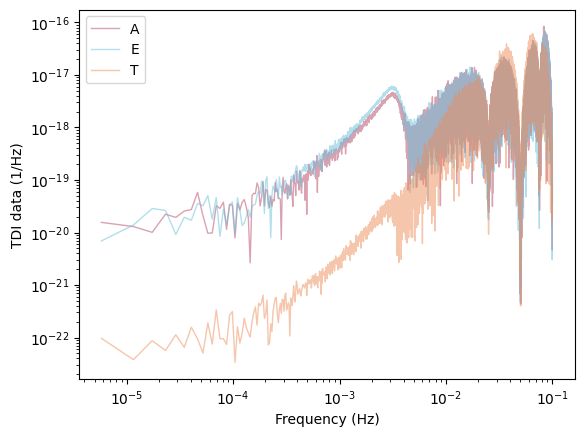

In [6]:
for i in range(3): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), color=channel_colors[i], label=channel_names[i], linewidth=1, alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TDI data (1/Hz)")
plt.legend()

## Select target frequency band 

In [7]:
fmin = 5e-5 
fmax = 1e-2 
freq_idx = np.where((data_frequency>=fmin+1e-4)&(data_frequency<=fmax-1e-4))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]

## Noise characterization 

In [8]:
# Tasd = 1. * DAY 
# data_before_idx = np.where((data_dict["time"]<=start_time)&(data_dict["time"]>=start_time-Tasd))[0]
# data_before = np.array(AETfromXYZ(data_dict["XYZ"]["X2"][data_before_idx], data_dict["XYZ"]["Y2"][data_before_idx], data_dict["XYZ"]["Z2"][data_before_idx]))
# psd_before = []
# for i in range(3): 
#     ff, xf = PSD_window(
#         data_array=data_before[i], 
#         fsample=1./dt, 
#         nbin=1, 
#         window_type="hann", 
#     )
#     psd_before.append(xf)
# psd_before = np.array(psd_before)
# psd_freq = ff 

# data_after_idx = np.where((data_dict["time"]<=end_time+Tasd)&(data_dict["time"]>=end_time))[0]
# data_after = np.array(AETfromXYZ(data_dict["XYZ"]["X2"][data_after_idx], data_dict["XYZ"]["Y2"][data_after_idx], data_dict["XYZ"]["Z2"][data_after_idx]))
# psd_after = []
# for i in range(3): 
#     ff, xf = PSD_window(
#         data_array=data_after[i], 
#         fsample=1./dt, 
#         nbin=1, 
#         window_type="hann", 
#     )
#     psd_after.append(xf)
# psd_after = np.array(psd_after)

# psd_channels = (psd_before + psd_after) / 2. 

# freq_idx = np.where((psd_freq>=fmin)&(psd_freq<=fmax))[0]
# psd_freq = psd_freq[freq_idx]
# psd_channels = psd_channels[:, freq_idx]

# psd_channels_smooth = np.zeros_like(psd_channels)
# for i in range(3): 
#     psd_channels_smooth[i] = savgol_filter(psd_channels[i], window_length=51, polyorder=3)
    
# psd_func_A = interp1d(x=psd_freq, y=psd_channels_smooth[0])
# psd_func_E = interp1d(x=psd_freq, y=psd_channels_smooth[1])
# psd_func_T = interp1d(x=psd_freq, y=psd_channels_smooth[2])

# # covariance matrix 
# CovMat = np.array([
#     [psd_func_A(data_frequency), np.zeros_like(data_frequency), np.zeros_like(data_frequency)],
#     [np.zeros_like(data_frequency), psd_func_E(data_frequency), np.zeros_like(data_frequency)],
#     [np.zeros_like(data_frequency), np.zeros_like(data_frequency), psd_func_T(data_frequency)]
# ]) / 4. * Tobs # (3, 3, Nf)

# # inverse of covmatrix
# InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) # (Nf, 3, 3)
# InvCovMat[:, 2, 2] = 0. 

In [9]:
# covariance matrix 
psdfunc = TDIPSDs()
CovMat = np.array([
    [psdfunc.PSD_A2(data_frequency), np.zeros_like(data_frequency), np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psdfunc.PSD_A2(data_frequency), np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), np.zeros_like(data_frequency), psdfunc.PSD_T2(data_frequency)]
]) / 4. * Tobs # (3, 3, Nf)

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) # (Nf, 3, 3)
InvCovMat[:, 2, 2] = 0. 

In [10]:
# for i in range(3): 
#     plt.loglog(psd_freq, psd_channels[i], label=channel_names[i], color=channel_colors[i], linewidth=1, alpha=0.5)
#     plt.loglog(psd_freq, psd_channels_smooth[i], color=channel_colors[i])
# psdfunc = TDIPSDs()
# plt.loglog(psd_freq, psdfunc.PSD_A2(psd_freq), linestyle="--", color="k")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("PSD (1/Hz)")
# plt.legend()

## Response model 

In [11]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    ) 

# initialize  waveform generator 
WFG = WaveformGeneratorFRef(
    mode="primary", 
)

# initialize response generator 
FDTDI = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

# response settings 
response_kwargs_interp = dict(
    fmin=fmin, # used to calculate freq grid
    fmax=fmax, # used to calculate freq grid
    fref=1e-3, # used to set reference point 
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=start_time/DAY, # minimum time of orbit in day 
    tmax=end_time/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True,
    interpolation_method='cubic',
    output_by_mode=False, 
)

response_kwargs_direct = dict(
    fref=1e-3, # used to set reference point 
    modes=[(2, 2)], 
    tmin=start_time/DAY, # minimum time of orbit in day 
    tmax=end_time/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True,
    interpolation_method=None, 
    output_by_mode=False, 
)

In [12]:
mbhb_idx = np.where((fiducial_parameters["coalescence_time"]>start_time/DAY)&(fiducial_parameters["coalescence_time"]<end_time/DAY))[0]

test_parameters = dict() 
for k, v in fiducial_parameters.items(): 
    if k not in ["reference_time", "reference_phase"]:
        test_parameters[k] = v[mbhb_idx]
test_parameters["reference_time"] = fiducial_parameters["coalescence_time"][mbhb_idx]
test_parameters["reference_phase"] = fiducial_parameters["coalescence_phase"][mbhb_idx]

wf_channels = FDTDI.Response(
    test_parameters, 
    data_frequency, 
    **response_kwargs_direct
)

mbhb_idx, test_parameters, wf_channels.shape 

(array([45]),
 {'chirp_mass': array([2148218.33967312]),
  'coalescence_phase': array([0.65740495]),
  'coalescence_time': array([322.51966869]),
  'inclination': array([0.97468481]),
  'latitude': array([-1.04878818]),
  'longitude': array([5.66193959]),
  'luminosity_distance': array([113910.90989008]),
  'mass_ratio': array([0.95562808]),
  'psi': array([1.68961367]),
  'spin_1z': array([-0.0261689]),
  'spin_2z': array([-0.691546]),
  'reference_time': array([322.52045685]),
  'reference_phase': array([0.65740495])},
 (3, 1685))

In [13]:
if len(test_parameters["chirp_mass"]) > 1: 
    wf_channels = np.sum(wf_channels, axis=1)
wf_channels.shape 

(3, 1685)

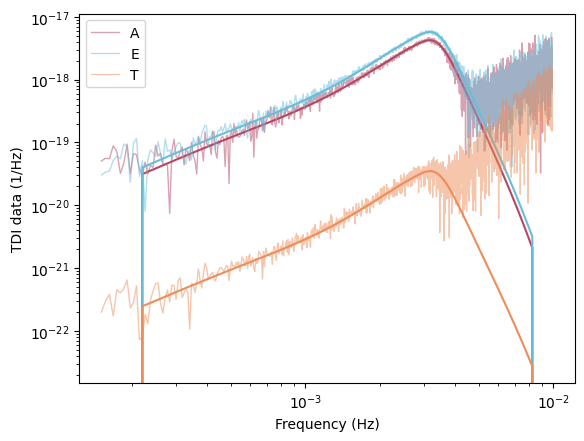

In [14]:
for i in range(3): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), color=channel_colors[i], label=channel_names[i], linewidth=1, alpha=0.5)
    plt.loglog(data_frequency, np.abs(wf_channels[i]), color=channel_colors[i])
plt.xlabel("Frequency (Hz)")
plt.ylabel("TDI data (1/Hz)")
plt.legend()

## MLE with  $\mathcal{F}$-stat 

### initialize F-stat 

In [15]:
Fstat = FstatisticsFref(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False
)

### set priors 

In [16]:
lgMc_prior = [4., 7.]
q_prior = [0.1, 0.99]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tref_prior = [start_time / DAY + 0.5, end_time / DAY - 0.5] 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tref_prior, 
    lam_prior, 
    sinbeta_prior, 
])

intrinsic_param_priors

array([[ 4.00000000e+00,  7.00000000e+00],
       [ 1.00000000e-01,  9.90000000e-01],
       [-9.00000000e-01,  9.00000000e-01],
       [-9.00000000e-01,  9.00000000e-01],
       [ 3.22000000e+02,  3.23000000e+02],
       [ 0.00000000e+00,  6.28318531e+00],
       [-1.00000000e+00,  1.00000000e+00]])

### optimization from prior 

In [17]:
from scipy.optimize import differential_evolution

def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    try:
        int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params) # (Nparams) -> dictionary
        return -Fstat.calculate_Fstat(intrinsic_parameters=params_in) # float
    except np.linalg.LinAlgError:
        return np.infty

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    # strategy='rand1bin',
    maxiter=1000,
    popsize=10*n_dim_int,
    # popsize=6*n_dim_int, 
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=True,
    # vectorized=True,
    workers=-1, 
)

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


In [18]:
print(DE_result)

             message: Optimization terminated successfully.
             success: True
                 fun: -209379.42168439424
                   x: [ 7.761e-01  7.468e-01  5.204e-01  2.318e-05
                        5.074e-01  6.645e-01  1.867e-01]
                 nit: 256
                nfev: 125970
          population: [[ 7.761e-01  7.468e-01 ...  6.645e-01  1.867e-01]
                       [ 7.760e-01  7.409e-01 ...  6.634e-01  1.802e-01]
                       ...
                       [ 7.762e-01  7.506e-01 ...  6.634e-01  1.857e-01]
                       [ 7.761e-01  7.475e-01 ...  6.642e-01  1.810e-01]]
 population_energies: [-2.094e+05 -2.094e+05 ... -2.094e+05 -2.094e+05]
                 jac: [-6.617e+02  9.793e+00  8.801e+00  3.405e+01
                       -2.941e+02  7.055e+00  2.101e+00]


### reconstruct parameters and waveforms 

In [19]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])

searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)

searched_params = dict(searched_int_params, **searched_ext_params)
searched_reflect_params = get_reflected_parameter_dict_Fref(searched_params, orbit)

searched_params, searched_reflect_params

({'chirp_mass': 2130141.3585677478,
  'mass_ratio': 0.7646700531757415,
  'spin_1z': 0.03675109892777095,
  'spin_2z': -0.8999582808018239,
  'reference_time': 322.50743201299775,
  'longitude': 4.175019743040979,
  'latitude': -0.6773014673976194,
  'luminosity_distance': 50254.22206989516,
  'inclination': 1.8662250237804243,
  'psi': 2.1648782283345094,
  'reference_phase': 1.7641787803259814},
 {'chirp_mass': 2130141.3585677478,
  'mass_ratio': 0.7646700531757415,
  'spin_1z': 0.03675109892777095,
  'spin_2z': -0.8999582808018239,
  'reference_time': 322.50743201299775,
  'longitude': 4.813102977907732,
  'latitude': -1.2390263213155694,
  'luminosity_distance': 50254.22206989516,
  'inclination': 1.2753676298093688,
  'psi': 2.9168840972818915,
  'reference_phase': 1.7641787803259814})

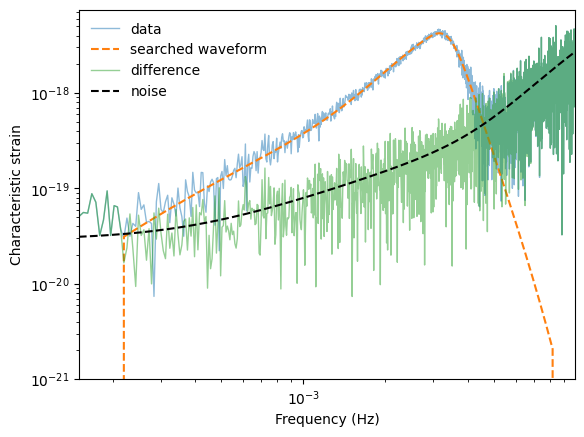

In [20]:
searched_wf1 = FDTDI.Response(
    searched_params, 
    data_frequency, 
    **response_kwargs_direct
)

k_fiducial = FDTDI.WaveVector(parameters=searched_params)
k_reflected = FDTDI.WaveVector(parameters=searched_reflect_params)
R1_tc = orbit.Positionfunctions()["1"](searched_params["reference_time"]*DAY)
R2_tc = orbit.Positionfunctions()["2"](searched_params["reference_time"]*DAY)
R3_tc = orbit.Positionfunctions()["3"](searched_params["reference_time"]*DAY)
R0_tc = (R1_tc + R2_tc + R3_tc) / 3. / C 
exp_factor_fiducial = np.exp(1.j * TWOPI * response_kwargs_interp["fref"] * np.dot(k_fiducial, R0_tc))
exp_factor_reflected = np.exp(1.j * TWOPI * response_kwargs_interp["fref"] * np.dot(k_reflected, R0_tc))

searched_wf2 = FDTDI.Response(
    searched_reflect_params, 
    data_frequency, 
    **response_kwargs_direct
) * exp_factor_reflected / exp_factor_fiducial

plt.loglog(data_frequency, np.abs(data_channels_fd[0]), label="data", linewidth=1, alpha=0.5)
plt.loglog(data_frequency, np.abs(searched_wf1[0]), linestyle="--", label="searched waveform")
# plt.loglog(data_frequency, np.abs(searched_wf2[0]), linestyle=":", label="searched waveform (reflected)")
plt.loglog(data_frequency, np.abs(searched_wf1[0] - data_channels_fd[0]), linestyle="-", linewidth=1, alpha=0.5, label="difference")
# plt.loglog(data_frequency, np.abs(searched_wf2[0] - data_channels_fd[0]), linestyle="-", linewidth=1, alpha=0.5, label="difference (reflected)")
# plt.loglog(psd_freq, np.sqrt(psd_channels_smooth[0] * Tobs / 2.), label="noise", color="k", linestyle="--")
plt.loglog(data_frequency, np.sqrt(psdfunc.PSD_A2(data_frequency) * Tobs / 2.), label="noise", color="k", linestyle="--")
plt.ylim(1e-21, )
plt.xlim(data_frequency[0], data_frequency[-1])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic strain")
plt.legend(loc="upper left", frameon=False)

In [21]:
FrequencyDomainCovarianceSNR(data_channels=searched_wf1, inv_cov=InvCovMat)

647.1158041669621

## Fisher analysis 

In [22]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        parameters=param_dict, 
        freqs=frequencies,  
        **response_kwargs_interp, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.001,
    'reference_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_params, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequency, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

In [23]:
print("parameter name | true value | bias | bias (reflected) | confidence interval")
for k, v in searched_params.items():
    if k not in ["reference_time", "reference_phase"]:
        print(k, test_parameters[k], np.abs(v-test_parameters[k]), np.abs(searched_reflect_params[k]-test_parameters[k]), FIM.param_errors[k])

parameter name | true value | bias | bias (reflected) | confidence interval
chirp_mass [2148218.33967312] [18076.98110537] [18076.98110537] 4847.001311158817
mass_ratio [0.95562808] [0.19095802] [0.19095802] 0.04177397926551743
spin_1z [-0.0261689] [0.06292] [0.06292] 0.16562568460176022
spin_2z [-0.691546] [0.20841228] [0.20841228] 0.25193692004263
longitude [5.66193959] [1.48691984] [0.84883661] 0.17768553420478594
latitude [-1.04878818] [0.37148671] [0.19023814] 0.15643040332277097
luminosity_distance [113910.90989008] [63656.68782018] [63656.68782018] 26399.99833059031
inclination [0.97468481] [0.89154022] [0.30068282] 0.13905406473509416
psi [1.68961367] [0.47526456] [1.22727042] 0.16987996807543063


## Nested sampling with bilby 

### Prior

In [35]:
priors = bilby.core.prior.PriorDict()
PRIOR_FACTOR = 6.
priors["chirp_mass"] = bilby.prior.Uniform(minimum=searched_params["chirp_mass"]-PRIOR_FACTOR*FIM.param_errors["chirp_mass"], maximum=searched_params["chirp_mass"]+PRIOR_FACTOR*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, searched_params["mass_ratio"]-PRIOR_FACTOR*FIM.param_errors["mass_ratio"]), maximum=min(0.999, searched_params["mass_ratio"]+PRIOR_FACTOR*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_params["spin_1z"]-PRIOR_FACTOR*FIM.param_errors["spin_1z"]), maximum=min(0.9, searched_params["spin_1z"]+PRIOR_FACTOR*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_params["spin_2z"]-PRIOR_FACTOR*FIM.param_errors["spin_2z"]), maximum=min(0.9, searched_params["spin_2z"]+PRIOR_FACTOR*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=searched_params["reference_time"]-PRIOR_FACTOR*FIM.param_errors["reference_time"], maximum=searched_params["reference_time"]+PRIOR_FACTOR*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(1e4, searched_params["luminosity_distance"]-PRIOR_FACTOR*FIM.param_errors["luminosity_distance"]), maximum=min(1e6, searched_params["luminosity_distance"]+PRIOR_FACTOR*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

priors

{'chirp_mass': Uniform(minimum=2101059.3507007947, maximum=2159223.366434701, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.5140261775826369, maximum=0.999, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=-0.9, maximum=0.9, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=-0.9, maximum=0.6116632394539562, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=322.50727304377165, maximum=322.50759098222386, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=10000.0, maximum=208654.21205343702, name='luminosity_distance', latex_label='$d_L$', unit=

### Likelihood

In [36]:
Like_direct = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_direct, 
    Fref_waveform=True, 
    use_gpu=False, 
    verbose=0
)

fiducial_param_arr = ParamDict2ParamArrFref(searched_params)
Like_direct.prepare_het_log_like(base_parameters=fiducial_param_arr)

In [37]:
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="full"):
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        
        if type == "full":
            self.likelihood = Like_direct.full_log_like 
        elif type == "het": 
            self.likelihood = Like_direct.het_log_like
        else: 
            raise ValueError("wrong likelihood type.")

    def log_likelihood(self):
        return self.likelihood(ParamDict2ParamArrFref(self.parameters))

In [38]:
BLike_het = bilby_likelihood_wrapper(type="het")

### sampling with het likelihood

In [39]:
import multiprocessing
ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result_het = bilby.run_sampler(
    likelihood=BLike_het, 
    priors=priors,
    sampler="nessai", 
    # sampler="dynesty", 
    nlive=3000, # dynesty / nessai 
    # walks=20, # dynesty 
    # nact=50, # dynesty 
    # maxmcmc=2000, # dynesty 
    stopping=0.5, # nessai 
    # dlogz=0.1, # dynesty 
    npool=ncpu, # use all cpus 
    injection_parameters=fiducial_parameters, 
    outdir="../../Samples",
    label="tribbh_example_phenTmbhb_het",
    plot=True,
    resume=False, 
    # resume=True, 
)

13:09 bilby INFO    : Running for label 'tribbh_example_phenTmbhb_het', output will be saved to '../../Samples'


number of cpus = 12


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
13:09 bilby INFO    : Analysis priors:
13:09 bilby INFO    : chirp_mass=Uniform(minimum=2101059.3507007947, maximum=2159223.366434701, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
13:09 bilby INFO    : mass_ratio=Uniform(minimum=0.5140261775826369, maximum=0.999, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
13:09 bilby INFO    : spin_1z=Uniform(minimum=-0.9, maximum=0.9, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
13:09 bilby INFO    : spin_2z=Uniform(minimum=-0.9, maximum=0.6116632394539562, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None)
13:09 bilby

10-09 13:09 nessai INFO    : Running Nessai version 0.14.0.post0
10-09 13:09 nessai INFO    : Starting multiprocessing pool with 12 processes
10-09 13:09 nessai INFO    : Initialising nested sampler
10-09 13:09 nessai WARNING : Multiprocessing pool has already been configured.
10-09 13:09 nessai WARNING : Removing unused keyword arguments ({'ensemble_fraction', 'n_steps', 'n_accept', 'marginalise_augment', 'plot_chain', 'plot_history', 'augment_dims', 'step_type', 'generate_augment', 'enforce_likelihood_threshold', 'n_marg', 'max_n_clusters', 'step_kwargs'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
10-09 13:09 nessai INFO    : Passing kwargs to FlowProposal: {'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_repar

13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby WARNING : Sampler is not initialized
13:24 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:24 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:24 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:24 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:24 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:24 bilby INFO    : 

10-09 13:24 nessai INFO    : Finished closing worker pool.
10-09 13:24 nessai INFO    : Checkpointing nested sampling


13:24 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130


SystemExit: 130

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
test_parameters

{'chirp_mass': array([2148218.33967312]),
 'coalescence_phase': array([0.65740495]),
 'coalescence_time': array([322.51966869]),
 'inclination': array([0.97468481]),
 'latitude': array([-1.04878818]),
 'longitude': array([5.66193959]),
 'luminosity_distance': array([113910.90989008]),
 'mass_ratio': array([0.95562808]),
 'psi': array([1.68961367]),
 'spin_1z': array([-0.0261689]),
 'spin_2z': array([-0.691546]),
 'reference_time': array([322.52045685]),
 'reference_phase': array([0.65740495])}

In [ ]:
result_het.plot_corner(save=True)

NameError: name 'result_het' is not defined

In [ ]:
for k, v in test_parameters.items(): 
    if k not in ["coalescence_time", "coalescence_phase"]:
        print(k, v, searched_params[k], searched_reflect_params[k])

chirp_mass [6301109.85843637 1938311.50869768  948252.13486173 1655772.19023232
  144882.07681983 2083011.91604992 2461142.81748617  637099.50778762
 2053358.73686789  135796.62221691  430813.53512855  710293.77707233
 4180656.38010106 2304817.05692089 2444813.37721959 3045843.74569863
 1586784.45597077  629200.00140672  706972.71824866 3389590.22205183
 2380007.64444597 1462778.57656864  709493.2953955  1249584.79564223
 1329688.08305229 2027909.82448386 2264669.33797994 1490051.72237505
  679831.85113284 3822343.50772209 4821942.03509325  207115.17823899
  640804.10970751 2944432.2010099  2097081.95920703 5736042.01718578
  417665.90785183  896234.00643451  808252.86433524 3658075.20220777
 3278612.06132416 3229668.58013144 3365093.84427428 1983926.5333947
 1060261.44300405 2148218.33967312  582495.98071172 1498586.23698415
 1456853.88966103  575168.63024633] 1489353.712795616 1489353.712795616
inclination [2.09881322 1.52193634 1.39799664 2.76989698 1.43206882 0.55043207
 1.56615521